In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from tqdm import tqdm
cm_to_inch=0.393701

import Optimal_transport as OT

In [2]:
def plot_circle(ax,center,radius,color,linestyle,scale_x=1,scale_y=1,res=100,full=False):
    
    phi=np.linspace(0,2*np.pi,res)
    
    x=center[0]+np.cos(phi)*radius*scale_x
    y=center[1]+np.sin(phi)*radius*scale_y
    
    if full:
        ax.fill(x,y,color=color,linestyle=linestyle)
        
    else:
        ax.plot(x,y,color=color,linestyle='solid')
    
    return y,np.sin(phi)
    
    

In [3]:
def reg_pulse(L,x_c,times):
    res=np.zeros(len(times))
    
    res[times>=x_c-L/2]=1
    res[times>=x_c+L/2]=0
    
    return res

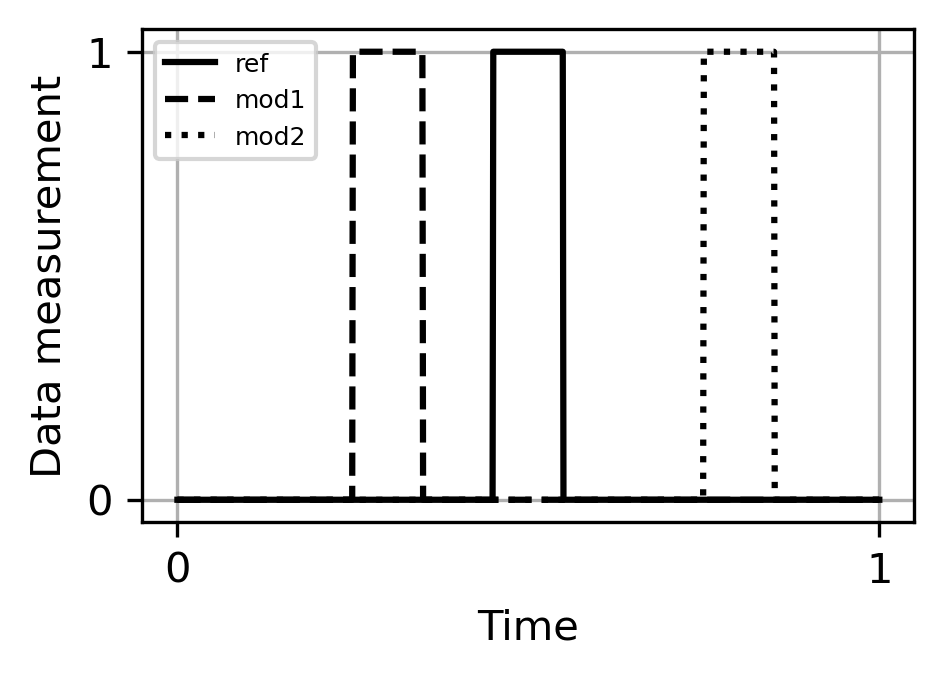

In [4]:
times=np.linspace(0,1,1001)
ref=reg_pulse(0.1,0.5,times)
mod1=reg_pulse(0.1,0.3,times)
mod2=reg_pulse(0.1,0.8,times)

plt.figure(figsize=(8.25*cm_to_inch,6*cm_to_inch),dpi=300)


ax=plt.axes()
ax.plot(times,ref,color='black',label='ref')
ax.plot(times,mod1,color='black',label='mod1',linestyle='dashed')
ax.plot(times,mod2,color='black',label='mod2',linestyle='dotted')

ax.set_xlabel('Time',fontsize=10)
ax.set_ylabel('Data measurement',fontsize=10)
ax.set_yticks([0,1])
ax.set_xticks([0,1])



plt.legend(fontsize=6)

plt.tight_layout()
plt.grid(True)

plt.show()

In [5]:
times=np.linspace(0,1,1001)

ref=reg_pulse(0.1,0.5,times)
shifts=np.linspace(-0.4,0.4,501)+1e-6

ErrsL2=[]
Errsot=[]
NSE=[]
mass=[]

vref=sum((ref-np.mean(ref))**2)


for i in tqdm(range(len(shifts))):
    mod=reg_pulse(0.1,0.5+shifts[i],times)
    ErrsL2.append(sum((mod-ref)**2))
    mass.append(sum(mod))
    NSE.append(1-(sum((mod-ref)**2))/vref)
    mod/=max(ref)
    
    Errsot.append(OT.optimal_transport(times,ref,times,mod,k1=0.2,k2=1.2))

100%|████████████████████████████████████████████████████████████████████████████████| 501/501 [00:34<00:00, 14.54it/s]


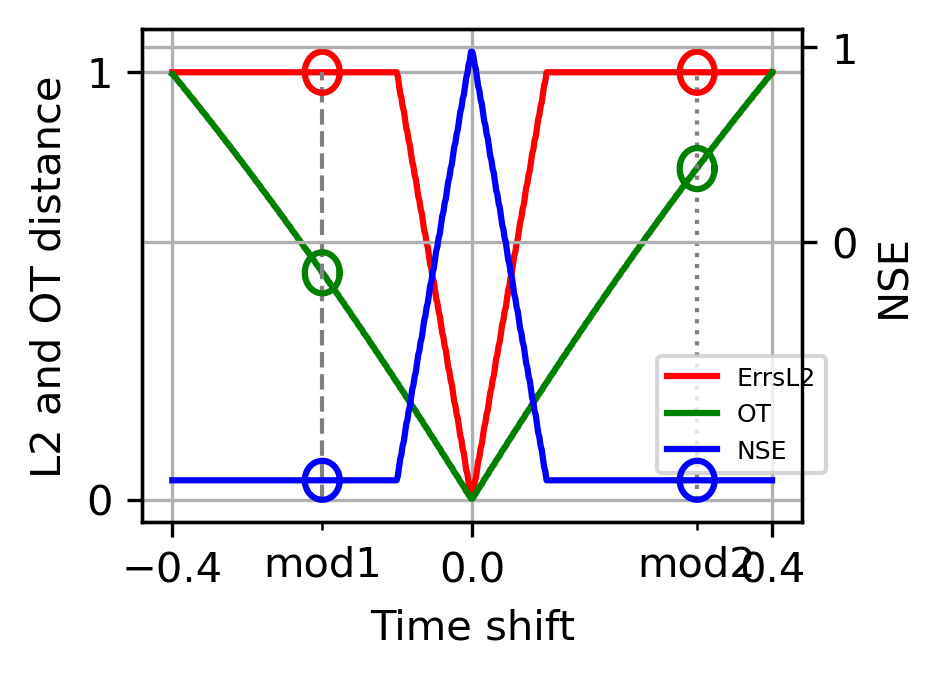

In [6]:
shifts=np.linspace(-0.4,0.4,501)

sx=8.25
sy=6

plt.figure(figsize=(sx*cm_to_inch,sy*cm_to_inch),dpi=300)



ax=plt.axes()
lns1=ax.plot(shifts,ErrsL2/max(ErrsL2),color='red',label='ErrsL2')
lns2=ax.plot(shifts,Errsot/max(Errsot),color='green',label='OT')

ax.plot([-0.2,-0.2],[0,1],color='grey',linestyle='dashed',linewidth=1)
ax.plot([0.3,0.3],[0,1],color='grey',linestyle='dotted',linewidth=1)


ax.set_xlabel('Time shift',fontsize=10)
ax.set_ylabel('L2 and OT distance',fontsize=10)
ax.set_yticks([0,1])
ax.set_xticks([-0.4,0,0.4])

ax.set_xticks([-0.2,0.3],labels=['mod1','mod2'],minor=True)

plot_circle(ax,center=[-0.2,1],radius=0.04,color='red',linestyle='dashed',scale_x=0.8*sy/sx,scale_y=1.2,res=100,full=False)
plot_circle(ax,center=[0.3,1],radius=0.04,color='red',linestyle='dotted',scale_x=0.8*sy/sx,scale_y=1.2,res=100,full=False)


plot_circle(ax,center=[-0.2,Errsot[125]/max(Errsot)],radius=0.04,color='green',linestyle='dashed',scale_x=0.8*sy/sx,scale_y=1.2,res=100,full=False)
plot_circle(ax,center=[0.3,Errsot[437]/max(Errsot)],radius=0.04,color='green',linestyle='dotted',scale_x=0.8*sy/sx,scale_y=1.2,res=100,full=False)


plt.tight_layout()

plt.grid(True)

ax2=plt.twinx(ax)

lns3=ax2.plot(shifts,NSE,color='blue',label='NSE')

plot_circle(ax2,center=[-0.2,min(NSE)],radius=0.04,color='blue',linestyle='dashed',scale_x=0.8*sy/sx,scale_y=2.5,res=100,full=False)
plot_circle(ax2,center=[0.3,min(NSE)],radius=0.04,color='blue',linestyle='dotted',scale_x=0.8*sy/sx,scale_y=2.5,res=100,full=False)



ax2.set_yticks([0,1])
ax2.set_ylabel('NSE',fontsize=10)

plt.tight_layout()


lns = lns1+lns2+lns3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=[0.78,0.1],fontsize=6)

plt.grid(True)

plt.show()
